In [39]:
import arviz as az
import pandas as pd
from anthropmass.bambi_model_module import *
az.style.use("arviz-darkgrid")

In [4]:
def summary(fitted):
    return az.summary(fitted)

In [5]:
def graph(model):
    return model.graph()

In [6]:
def plot_prior_predictive(model):
    prior_pred = model.prior_predictive(draws=1000)
    az.plot_ppc(prior_pred, group='prior')

In [21]:
def plot_posterior_predictive(model, fitted):
    model.predict(fitted, kind='response')
    az.plot_ppc(fitted)

In [8]:
def plot_forest(fitted, variables:list):
    az.plot_forest(fitted, var_names=variables)

In [28]:
def plot_hdi_priors(model):
    model.plot_priors()

In [29]:
def plot_hdi_posteriors(fitted, variables:list):
    az.plot_posterior(fitted, var_names=variables)

In [11]:
def plot_trace(fitted, variables:list):
    az.plot_trace(fitted, compact=False, var_names=variables)

In [43]:
train=pd.read_csv('../data/processed/ANSURIIminusmeanstrain.csv')

FileNotFoundError: [Errno 2] No such file or directory: '../data/processed/ANSURIIminusmeanstrain.csv'

In [36]:
model0, fitted0 = make_model('neckcircumference', train, '0 + C(Gender) + Component + weightkg + stature')

Initializing NUTS using adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [sigma, C(Gender), Component, weightkg, stature]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 182 seconds.


In [37]:
summary(fitted0)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
sigma,14.089,0.142,13.831,14.353,0.002,0.002,5755.0,5201.0,1.0
C(Gender)[0],345.277,5.148,335.848,355.203,0.101,0.067,2579.0,3501.0,1.0
C(Gender)[1],394.440,5.477,383.964,404.539,0.108,0.071,2579.0,3566.0,1.0
Component[Army Reserve],0.615,1.121,-1.532,2.698,0.015,0.012,5845.0,5160.0,1.0
Component[Regular Army],-0.970,0.415,-1.738,-0.187,0.005,0.005,6030.0,5190.0,1.0
weightkg,1.613,0.018,1.581,1.647,0.000,0.000,5182.0,5168.0,1.0
stature,-0.076,0.003,-0.083,-0.070,0.000,0.000,2492.0,3624.0,1.0


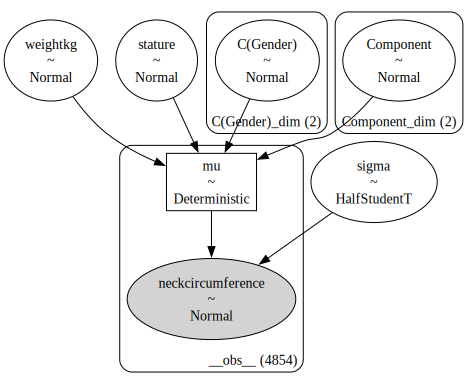

In [18]:
graph(model0)

Sampling: [C(Gender), Component, neckcircumference, sigma, stature, weightkg]


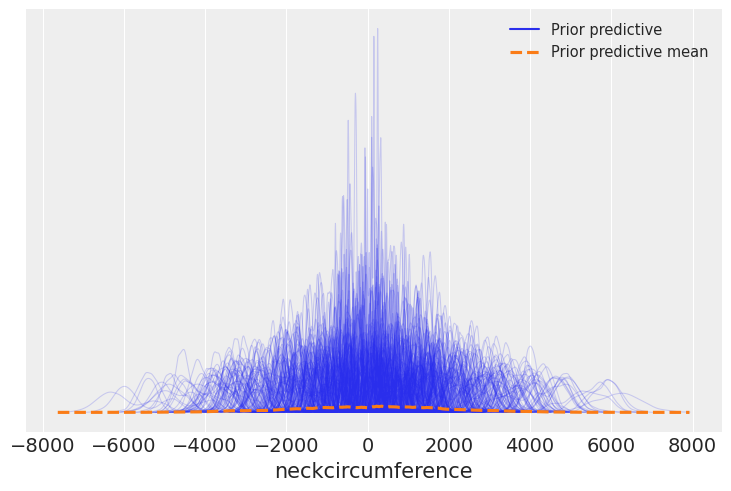

In [19]:
plot_prior_predictive(model0)

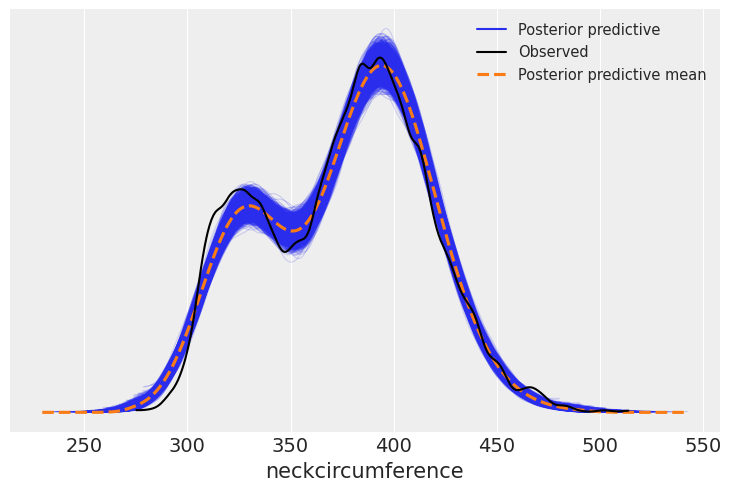

In [ ]:
plot_posterior_predictive(model0, fitted0)

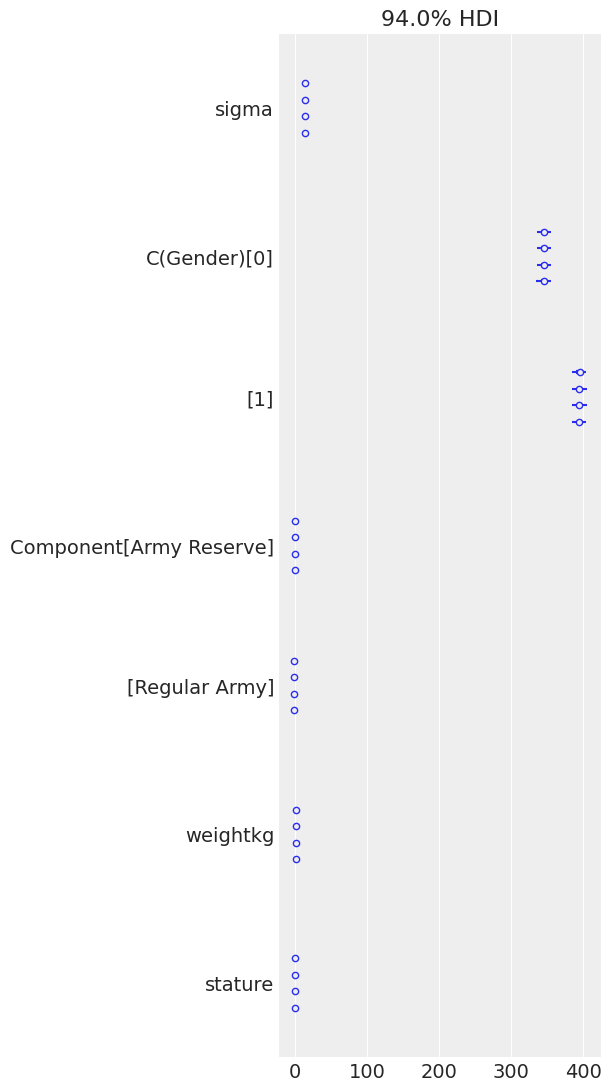

In [25]:
plot_forest(fitted0, variables= ["sigma", "C(Gender)", "Component", "weightkg", "stature"])

Sampling: [C(Gender), Component, sigma, stature, weightkg]


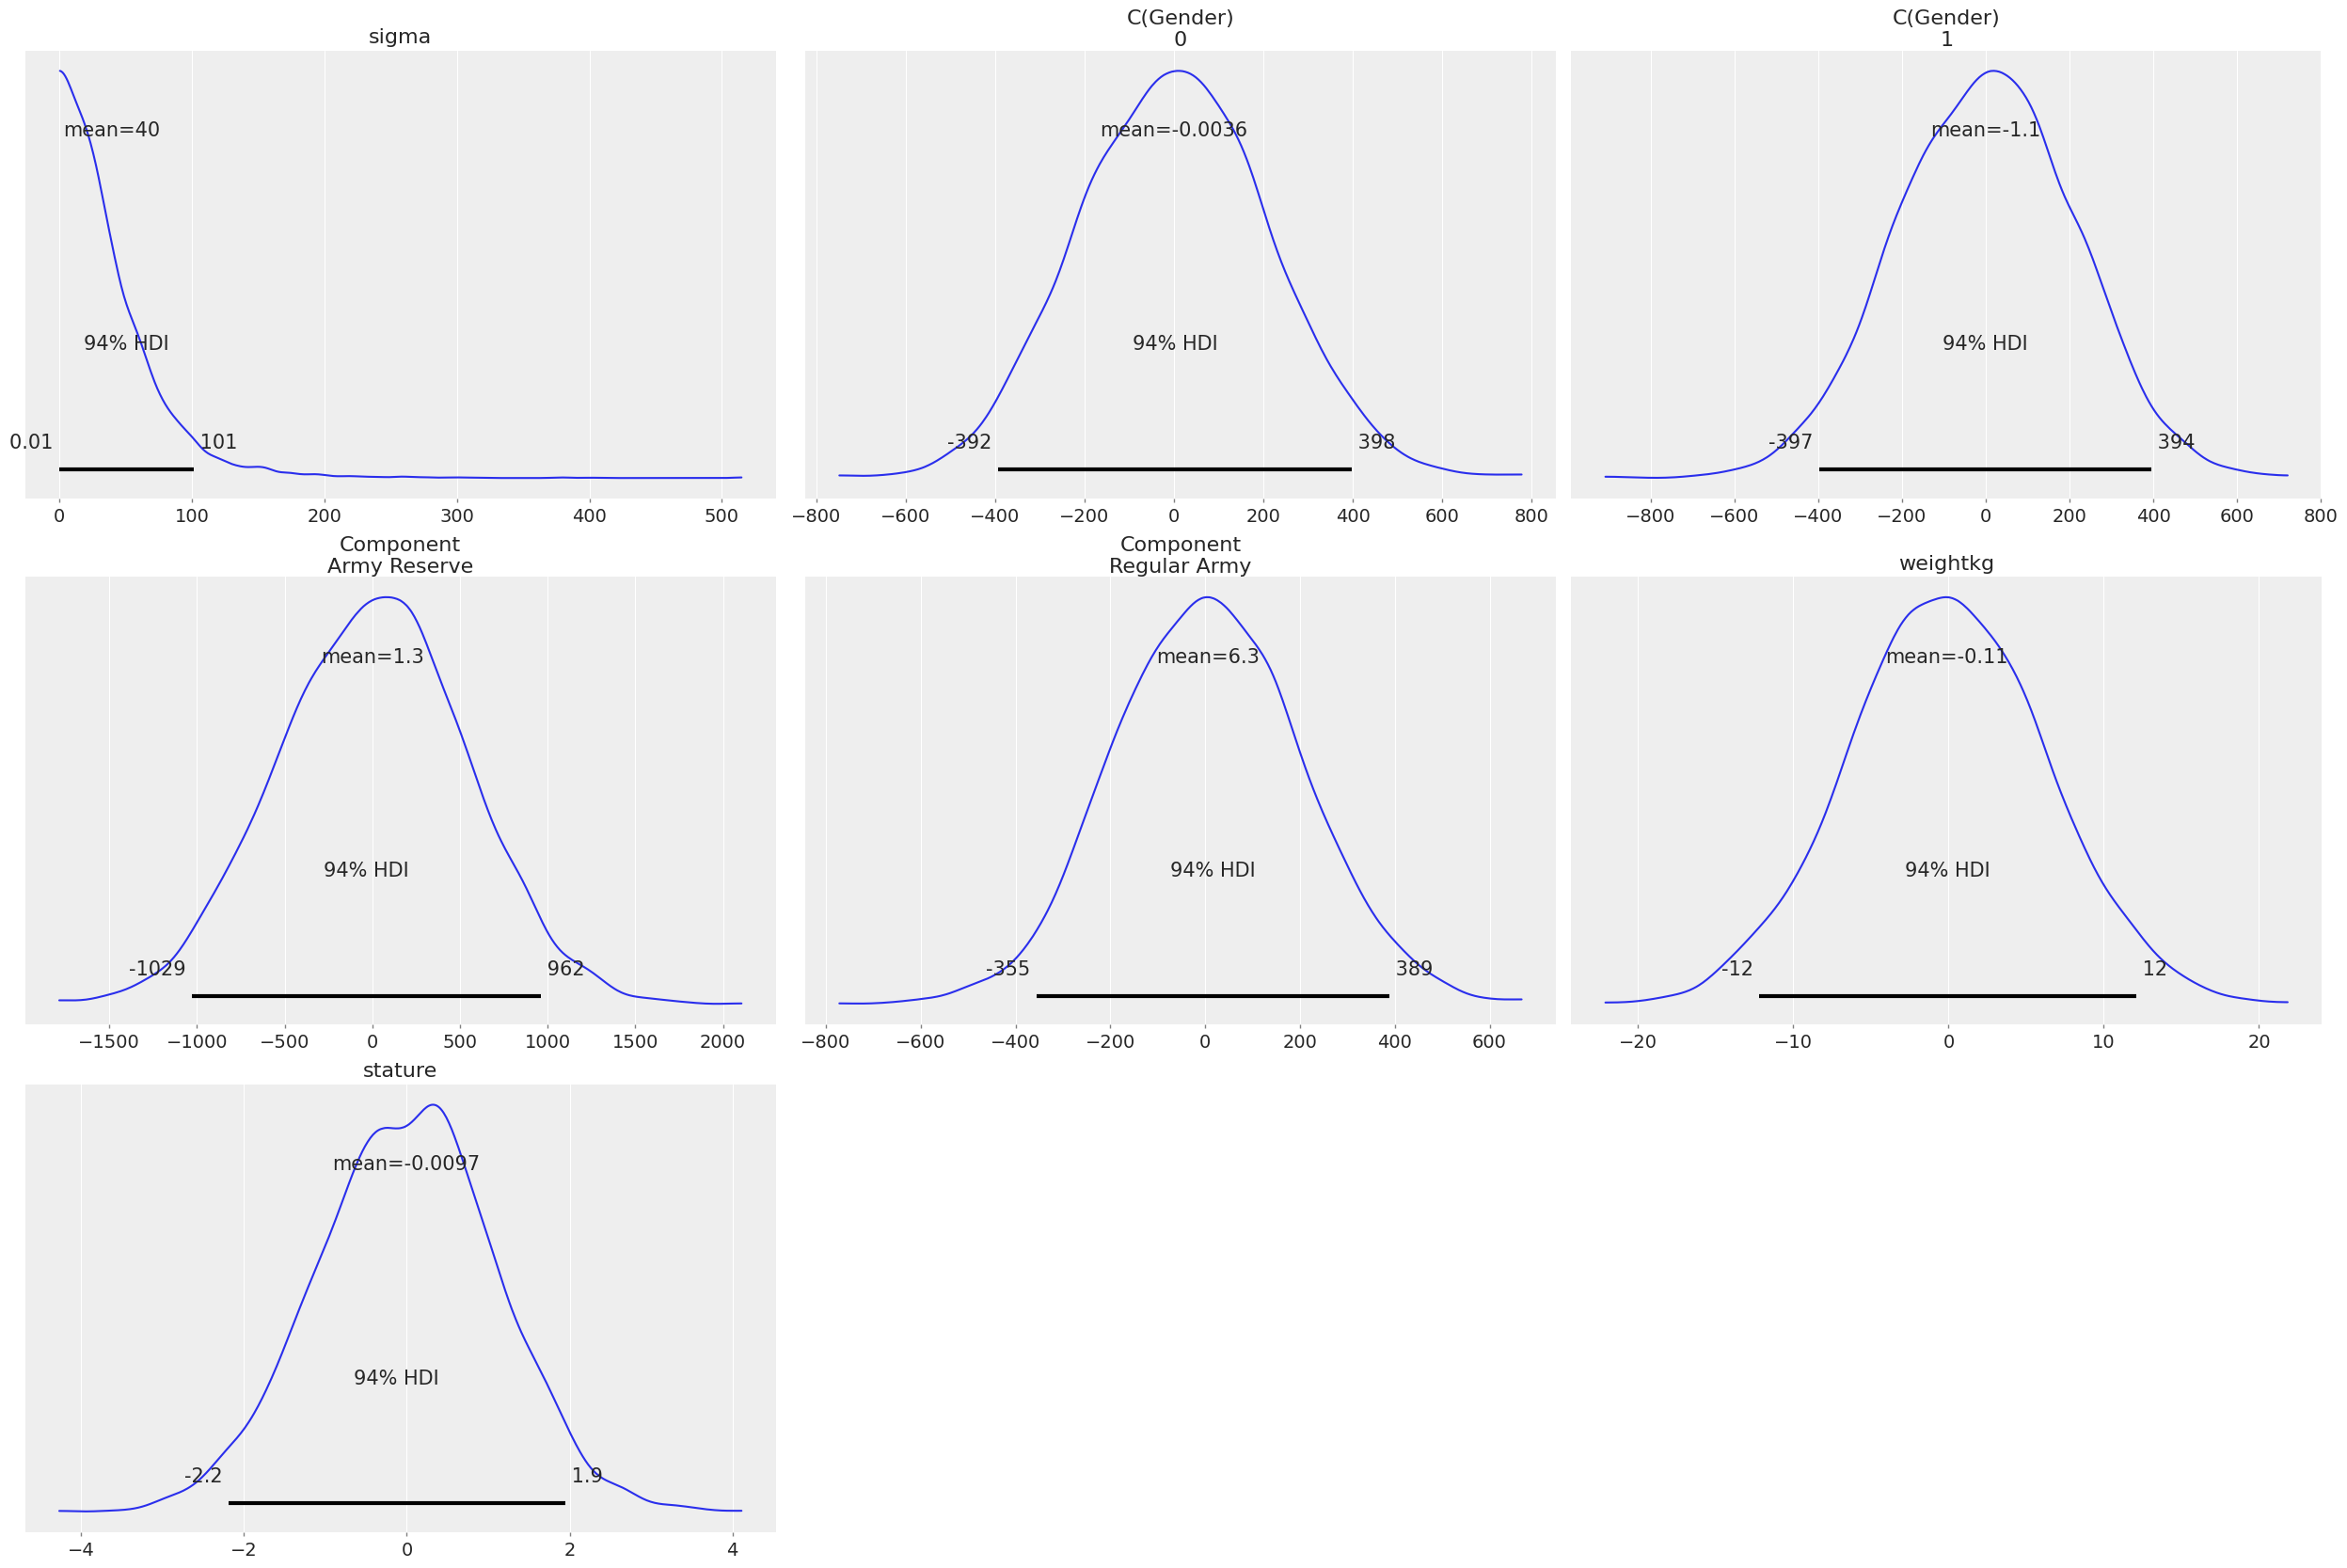

In [32]:
plot_hdi_priors(model0)

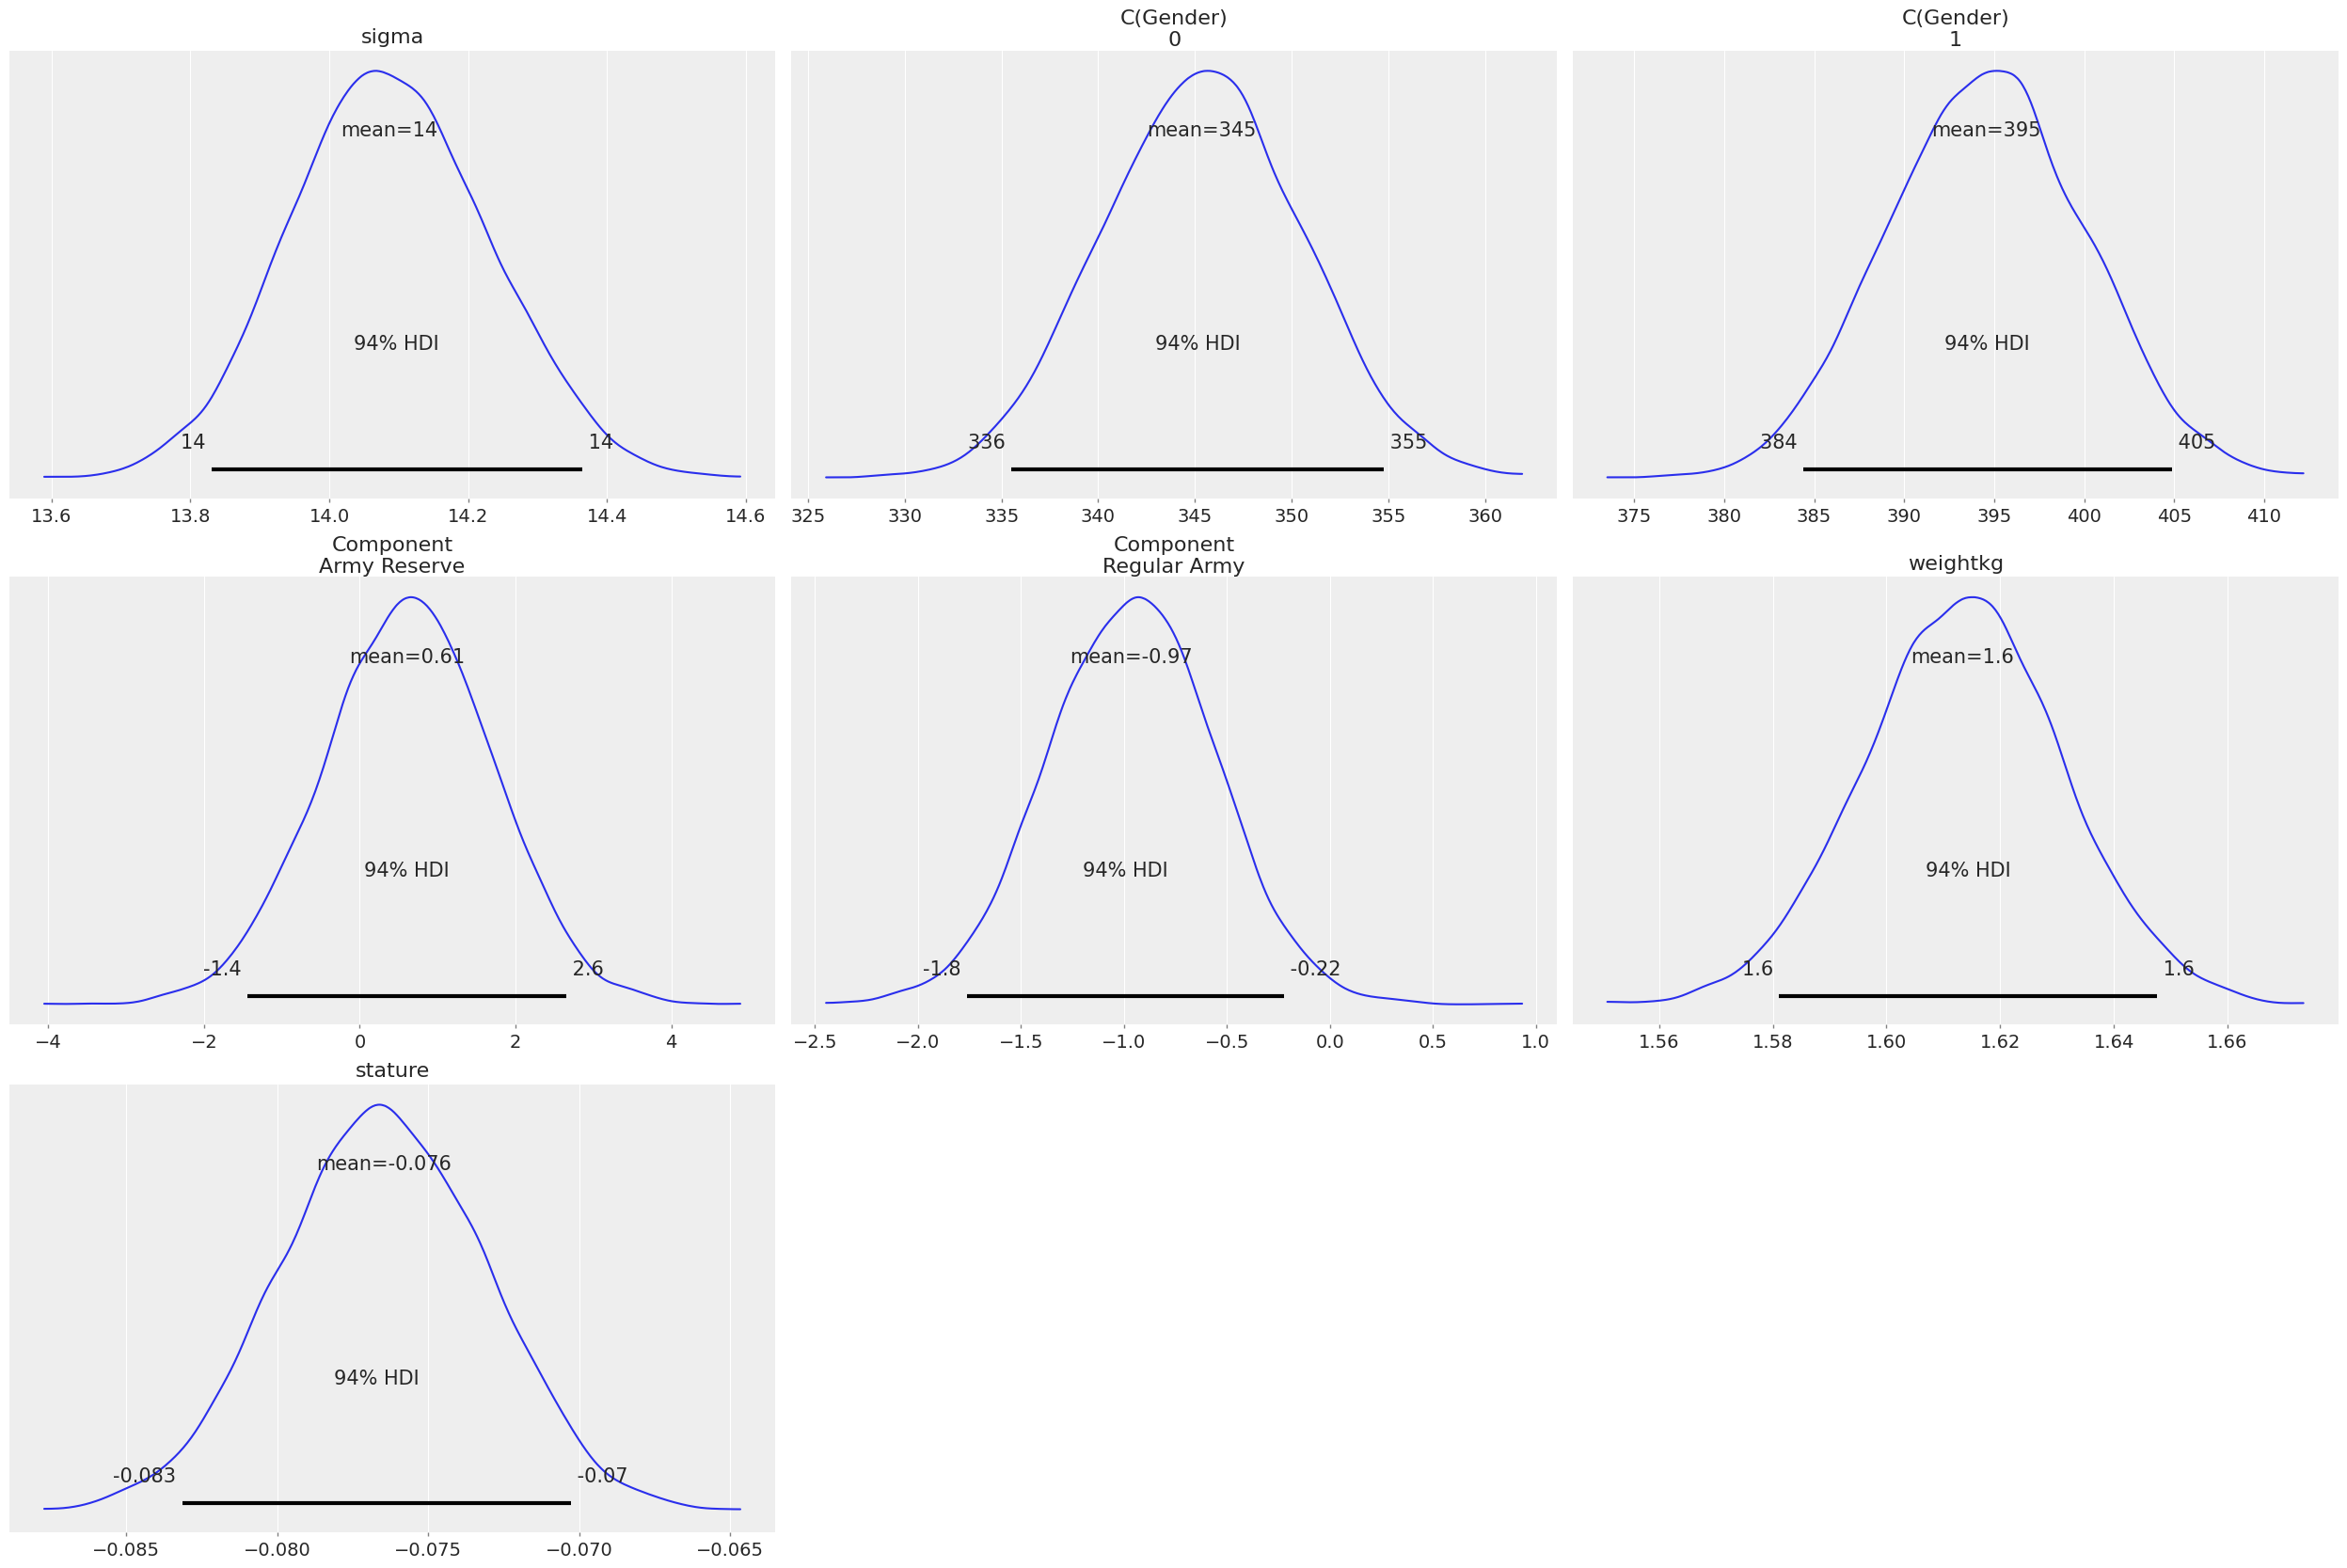

In [31]:
plot_hdi_posteriors(fitted0, variables=  ["sigma", "C(Gender)", "Component", "weightkg", "stature"])

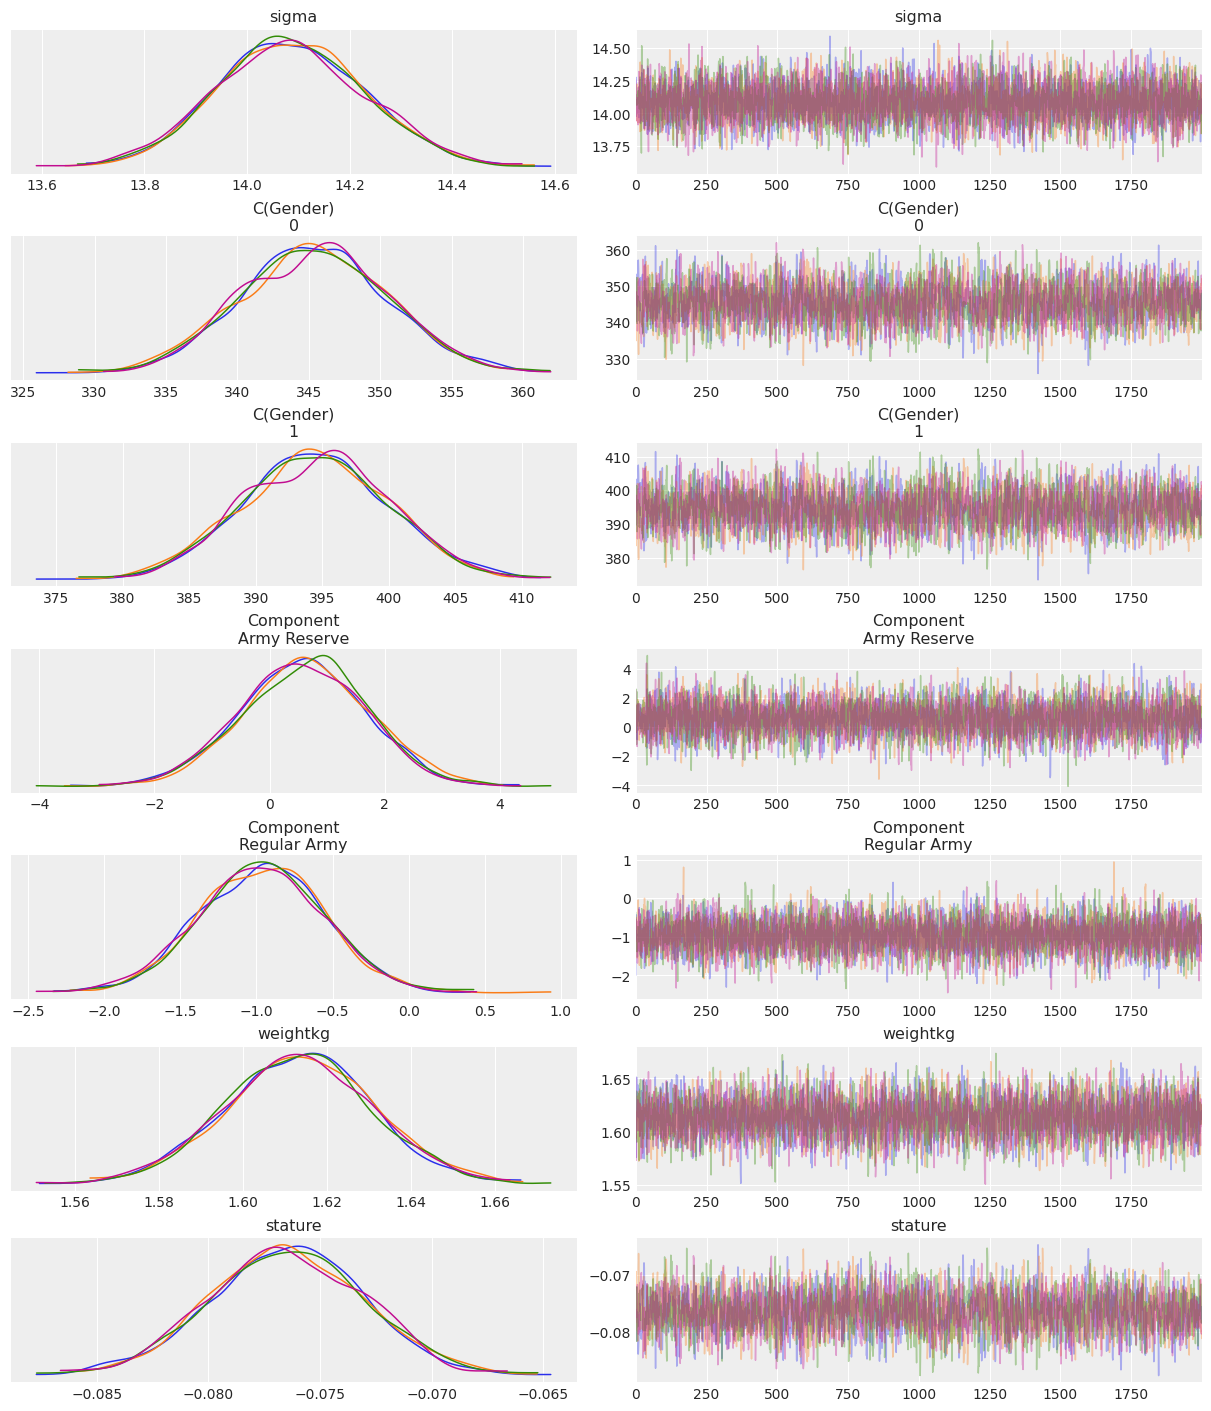

In [33]:
plot_trace(fitted0, variables= ["sigma", "C(Gender)", "Component", "weightkg", "stature"])